# 07 — Nos données terrain Hanoï

**Le maillon entre la collecte (ODK/Kobo) et le modèle (notebook 08).**

Ce notebook fait tout le travail sur NOS données :
1. Charge l'export CSV de KoboToolbox
2. Nettoie (même pipeline que le notebook 02 sur Sunbird)
3. Enrichit avec la météo (API Open-Meteo, gratuite)
4. Analyses de la Phase 3 du plan : time-series par site, transport vs chantier, dépassements de normes
5. Sauvegarde `data/raw/hanoi/measurements.csv` → consommé par le notebook 08

**Comment exporter depuis Kobo :** ton projet → Data → Downloads → CSV → place le fichier dans `data/raw/hanoi/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import glob

# Le CSV exporté de Kobo (on exclut measurements.csv, qui est NOTRE sortie)
files = [f for f in glob.glob('../data/raw/hanoi/*.csv')
         if not f.endswith('measurements.csv')]
print('Fichiers trouvés :', files)
raw = pd.read_csv(files[0], sep=';')  # Kobo exporte en ';' — mets ',' si erreur
if len(raw.columns) == 1:  # mauvais séparateur
    raw = pd.read_csv(files[0], sep=',')
print(f'{len(raw)} soumissions')
raw.head(3)

Fichiers trouvés : ['../data/raw/hanoi/Hanoi_Urban_Noise_Survey_-_all_versions_-_labels_-_2026-06-12-06-56-20.csv']
21 soumissions


/Users/phocidae/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


,start,end,Study site,Who is collecting?,GPS location (wait for accuracy < 10 m),_GPS location (wait for accuracy < 10 m)_latitude,_GPS location (wait for accuracy < 10 m)_longitude,_GPS location (wait for accuracy < 10 m)_altitude,_GPS location (wait for accuracy < 10 m)_precision,Audio recording (>= 10 seconds),...,_uuid,_submission_time,_validation_status,_notes,_status,_submitted_by,__version__,_tags,meta/rootUuid,_index
0,2026-06-10T14:33:42.770+07:00,2026-06-10T16:05:57.341+07:00,Ocean Park,Lucas,20.9922001 105.9442618 -18.799999237060547 4.94,20.992200,105.944262,-18.799999,4.940,1781082310560.m4a,...,cc2ee543-ad19-47fc-9dd3-f7e750186b1f,2026-06-10T09:07:02,NaN,NaN,submitted_via_web,lucasz,vjhxx5yYjcPFHB243SaKoN,NaN,uuid:cc2ee543-ad19-47fc-9dd3-f7e750186b1f,1
1,2026-06-10T21:38:50.850+07:00,2026-06-10T21:40:43.952+07:00,Ocean Park,Lucas,20.9931116 105.9431169 -19.200000762939453 4.409,20.993112,105.943117,-19.200001,4.409,1781102389995.m4a,...,1e5fa39d-b461-4cb2-b491-28fb6e593c54,2026-06-10T14:40:54,NaN,NaN,submitted_via_web,lucasz,vjhxx5yYjcPFHB243SaKoN,NaN,uuid:1e5fa39d-b461-4cb2-b491-28fb6e593c54,2
2,2026-06-11T10:53:59.687+07:00,2026-06-11T10:57:02.173+07:00,Ocean Park,Lucas,20.9925363 105.9434721 -18.899999618530273 4.724,20.992536,105.943472,-18.900000,4.724,1781150190566.m4a,...,25252429-55c3-4d7a-9960-68d3b8c57fcb,2026-06-11T03:57:11,NaN,NaN,submitted_via_web,lucasz,vjhxx5yYjcPFHB243SaKoN,NaN,uuid:25252429-55c3-4d7a-9960-68d3b8c57fcb,3


In [2]:
# ---- Mise au format standard ----
# Kobo a deux modes d'export : "names" (site, noise_db, _location_latitude...)
# et "labels" (Study site, Noise level (dB)...). On détecte la colonne par
# sous-chaîne pour supporter les deux.

def col(*keys):
    """Première colonne de raw dont le nom contient une des clés (insensible à la casse)."""
    for k in keys:
        for c in raw.columns:
            if k.lower() in c.lower():
                return raw[c]
    return None

df = pd.DataFrame({
    # timestamps Kobo en heure locale +07:00 — on retire le fuseau (tout est local Hanoï)
    'timestamp':  pd.to_datetime(col('start'), format='ISO8601', utc=True)
                    .dt.tz_convert('Asia/Bangkok').dt.tz_localize(None),
    'latitude':   pd.to_numeric(col('_latitude', 'location_latitude')),
    'longitude':  pd.to_numeric(col('_longitude', 'location_longitude')),
    'altitude':   pd.to_numeric(col('_altitude', 'location_altitude')),
    'accuracy':   pd.to_numeric(col('_precision', 'location_precision')),
    'noise_dB':   pd.to_numeric(col('noise level', 'noise_db')),
    'class':      col('noise category', 'noise_class'),
    'site':       col('study site', 'site'),
    'collector':  col('who is collecting', 'collector'),
    'dist_to_road': col('distance to nearest road', 'dist_to_road'),
    'note':       col('note'),
})
df['collector'] = df['collector'].str.strip().str.lower()

# ---- Nettoyage : même pipeline que le notebook 02 sur Sunbird ----
n0 = len(df)
df = df.dropna(subset=['noise_dB', 'latitude', 'longitude'])
df = df.drop_duplicates(subset=['collector', 'timestamp'])
df = df[df['accuracy'].isna() | (df['accuracy'] < 50)]
df = df[(df['noise_dB'] >= 20) & (df['noise_dB'] <= 120)]

# Calibration croisée (voir field/CALIBRATION.md) :
# si les offsets sont entrés dans le Trim de Decibel X → laisser à 0 ici.
# Sinon, mettre les offsets mesurés (référence - téléphone).
CALIBRATION_OFFSET = {'laurian': 0.0, 'lucas': 0.0, 'quang': 0.0}
df['noise_dB'] = df['noise_dB'] + df['collector'].map(CALIBRATION_OFFSET).fillna(0)

df['hour'] = df['timestamp'].dt.hour
df['is_weekend'] = df['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)
df['day_of_week'] = df['timestamp'].dt.day_name()
print(f'{n0} brutes → {len(df)} mesures propres')
df[['timestamp', 'site', 'collector', 'noise_dB', 'accuracy', 'dist_to_road']].head()

21 brutes → 21 mesures propres


,timestamp,site,collector,noise_dB,accuracy,dist_to_road
0,2026-06-10 14:33:42.770,Ocean Park,lucas,75.0,4.940,0-10 m
1,2026-06-10 21:38:50.850,Ocean Park,lucas,70.0,4.409,10-30 m
2,2026-06-11 10:53:59.687,Ocean Park,lucas,65.0,4.724,10-30 m
3,2026-06-11 10:59:08.473,Ocean Park,lucas,70.0,5.525,0-10 m
4,2026-06-11 11:16:15.198,Ocean Park,lucas,65.0,3.688,10-30 m


## Météo — API Open-Meteo (gratuite, sans clé)

Le plan demande les conditions météo par mesure. On les récupère depuis les timestamps.

In [3]:
import time

def get_weather(lat, lon, date_str, retries=3):
    """Météo horaire pour un jour donné — un appel par jour/site suffit."""
    for attempt in range(retries):
        try:
            r = requests.get('https://archive-api.open-meteo.com/v1/archive', params={
                'latitude': lat, 'longitude': lon,
                'start_date': date_str, 'end_date': date_str,
                'hourly': 'temperature_2m,wind_speed_10m,precipitation,relative_humidity_2m',
                'timezone': 'Asia/Bangkok',
            }, timeout=30)
            h = r.json()['hourly']
            return pd.DataFrame(h).assign(time=lambda x: pd.to_datetime(x['time']))
        except Exception as e:
            print(f'  tentative {attempt + 1}/{retries} échouée ({type(e).__name__}), retry...')
            time.sleep(5)
    return None

# Un appel par (jour, site) puis merge sur l'heure la plus proche.
# Si l'API est injoignable, on continue SANS météo (récupérable plus tard :
# l'API archive permet de re-fetch n'importe quelle date passée).
weather_frames = []
for (date, site), g in df.groupby([df['timestamp'].dt.date, 'site']):
    w = get_weather(g['latitude'].mean(), g['longitude'].mean(), str(date))
    if w is not None:
        w['site'] = site
        weather_frames.append(w)

if weather_frames:
    weather = pd.concat(weather_frames)
    df['time_h'] = df['timestamp'].dt.floor('h')
    df = df.merge(
        weather.rename(columns={'time': 'time_h'}),
        on=['time_h', 'site'], how='left'
    ).drop(columns='time_h')
    print('Météo ajoutée :', [c for c in ['temperature_2m','wind_speed_10m','precipitation'] if c in df.columns])
else:
    print('API Open-Meteo injoignable — on continue sans météo (relance cette cellule plus tard).')

Météo ajoutée : ['temperature_2m', 'wind_speed_10m', 'precipitation']


## Phase 3 du plan — Analyses

### Normes utilisées
| Norme | Jour (6h-21h) | Nuit (21h-6h) |
|---|---|---|
| **QCVN 26:2010/BTNMT** (Vietnam, zone ordinaire) | 70 dB | 55 dB |
| **OMS** (recommandation trafic) | 53 dB | 45 dB |

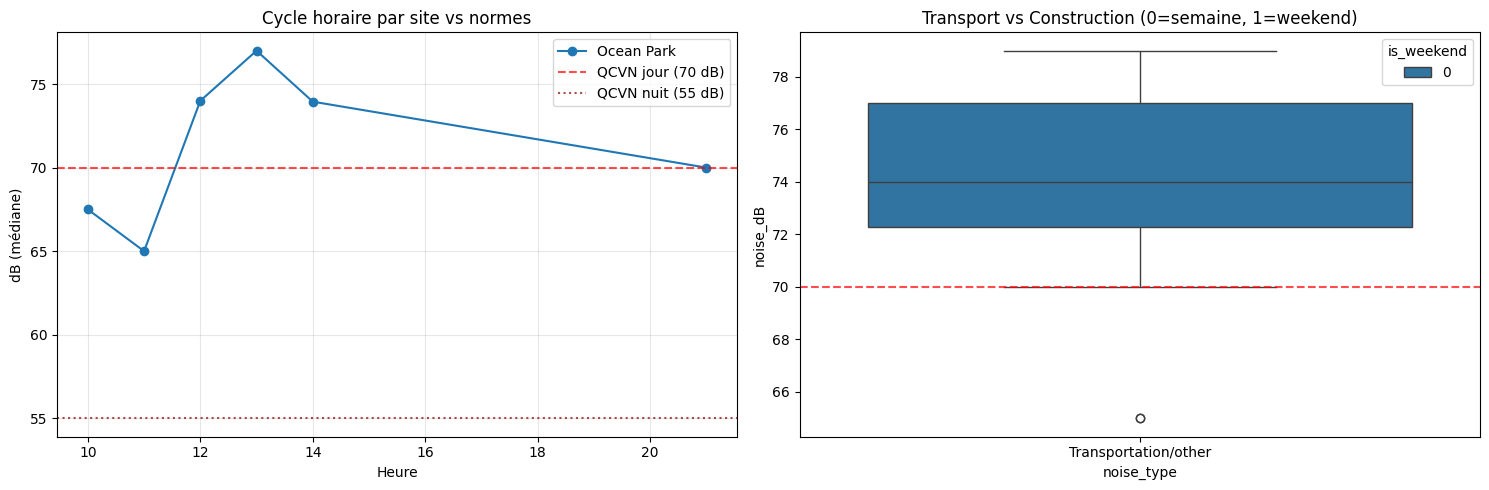

In [4]:
# Time-series par site : cycle horaire (médiane + IQR, comme la Fig. 9 du papier)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for site, g in df.groupby('site'):
    h = g.groupby('hour')['noise_dB'].median()
    axes[0].plot(h.index, h.values, marker='o', label=site)
axes[0].axhline(70, color='red', linestyle='--', alpha=0.7, label='QCVN jour (70 dB)')
axes[0].axhline(55, color='darkred', linestyle=':', alpha=0.7, label='QCVN nuit (55 dB)')
axes[0].set_xlabel('Heure'); axes[0].set_ylabel('dB (médiane)')
axes[0].set_title('Cycle horaire par site vs normes')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Transport vs construction (demandé par le plan)
df['noise_type'] = np.where(df['class'] == 'construction_site', 'Construction', 'Transportation/other')
sns.boxplot(data=df, x='noise_type', y='noise_dB', hue='is_weekend', ax=axes[1])
axes[1].axhline(70, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('Transport vs Construction (0=semaine, 1=weekend)')

plt.tight_layout()
plt.savefig('../outputs/maps/hanoi_phase3_analysis.png', dpi=150)
plt.show()

In [5]:
# Dépassements de normes : fréquence et sévérité (demandé par le plan)
df['period'] = np.where((df['hour'] >= 21) | (df['hour'] < 6), 'night', 'day')
df['qcvn_limit'] = np.where(df['period'] == 'day', 70, 55)
df['exceeds_qcvn'] = df['noise_dB'] > df['qcvn_limit']
df['exceed_by'] = (df['noise_dB'] - df['qcvn_limit']).clip(lower=0)

summary = df.groupby(['site', 'period']).agg(
    n=('noise_dB', 'count'),
    median_dB=('noise_dB', 'median'),
    pct_exceed=('exceeds_qcvn', lambda x: 100 * x.mean()),
    mean_exceed_dB=('exceed_by', lambda x: x[x > 0].mean()),
).round(1)
print('=== Dépassements QCVN 26:2010/BTNMT par site ===')
print(summary)
summary.to_csv('../outputs/hanoi_exceedances.csv')

=== Dépassements QCVN 26:2010/BTNMT par site ===
                    n  median_dB  pct_exceed  mean_exceed_dB
site       period                                           
Ocean Park day     20       74.5        80.0             5.4
           night    1       70.0       100.0            15.0


In [6]:
# ---- Sauvegarde finale : input du notebook 07 (calibration du modèle) ----
out = df[['latitude', 'longitude', 'noise_dB', 'timestamp', 'class', 'site',
          'hour', 'is_weekend'] +
         [c for c in ['temperature_2m', 'wind_speed_10m', 'precipitation'] if c in df.columns]]
out.to_csv('../data/raw/hanoi/measurements.csv', index=False)
print(f'{len(out)} mesures → data/raw/hanoi/measurements.csv')
print('Prochaine étape : notebook 08 (la cellule calibration se décommente et tourne)')

21 mesures → data/raw/hanoi/measurements.csv
Prochaine étape : notebook 07 (la cellule calibration se décommente et tourne)


In [7]:
# Carte des points de mesure (fond OpenStreetMap)
import folium

m = folium.Map(location=[df.latitude.mean(), df.longitude.mean()],
               zoom_start=16, tiles='OpenStreetMap')

def color(db):
    return 'green' if db < 60 else 'orange' if db < 70 else 'red' if db < 80 else 'darkred'

for _, r in df.iterrows():
    folium.CircleMarker(
        [r.latitude, r.longitude], radius=7,
        color=color(r.noise_dB), fill=True, fill_opacity=0.9,
        popup=f"{r.noise_dB:.0f} dB — {r['class']}<br>{r.timestamp:%d/%m %H:%M} — {r.collector}",
        tooltip=f'{r.noise_dB:.0f} dB',
    ).add_to(m)

legend = '''<div style="position:fixed;bottom:20px;left:20px;z-index:9999;background:white;
padding:10px;border:1px solid #888;border-radius:6px;font-size:13px">
<b>Mesures terrain (n=%d)</b><br>
<span style="color:green">&#9679;</span> &lt; 60 dB &nbsp;
<span style="color:orange">&#9679;</span> 60-70 &nbsp;
<span style="color:red">&#9679;</span> 70-80 &nbsp;
<span style="color:darkred">&#9679;</span> &gt; 80</div>''' % len(df)
m.get_root().html.add_child(folium.Element(legend))
m.save('../outputs/maps/hanoi_field_points.html')
m